In [279]:
import numpy as np
import glob
import scipy as sc
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.special import erfc
from fit_functions import R_sq, EMG, EMG_mirrored, EMGsTailFront, make_constrained_EMG, make_constrained_EMG_mirrored, make_constrained_EMGsTailFront, make_sigma_constrained_EMG, make_sigma_constrained_EMG_mirrored, make_sigma_constrained_EMGsTailFront


## Calibration

In [280]:
# Calibration data, all masses in g, all areas in arbitrary units, all concentrations in wt% (mass of solute / total mass)
FA = {
    'name': 'Formic Acid',
    'water': np.array([1, 0.9708, 0.9620, 0.9157, 0.9194, 0.9276, 1.1981]),
    'FA': np.array([0, 0.0410, 0.0758, 0.2071, 0.4549, 0.1422, 0.0191]),
    'areas': np.array([0, 556879, 984689, 2469722, 4456892, 1782368, 198684])
}
FAld = {
    'name': 'Formaldehyde',
    'water': np.array([1, 0.8533, 0.8868, 0.7250, 0.5555, 1.0525]),
    'FAld': np.array([0, 0.4061, 0.2224, 0.4548, 0.6975, 0.1297]),
    'areas': np.array([0, 3277991, 1975810, 3911989, 5744917, 1078320])
}

# Convert masses to wt% concentration for each calibration series
calibrations = [
    (FA, 'FA', 100),
    (FAld, 'FAld', 37),
]

for dictionary, solute_key, factor in calibrations:
    # wt% = mass of solute / total mass, scaled by mass concentration factor in stock solution (100% for FA, 37% for FAld)
    concentrations = factor * dictionary[solute_key] / (dictionary[solute_key] + dictionary['water'])
    order = np.argsort(concentrations)
    dictionary['concentrations'] = concentrations[order]
    dictionary['areas'] = dictionary['areas'][order]

col_width = 20
header = f"{'Formaldehyde wt%':^{col_width}} {'Formic Acid wt%':^{col_width}}"
print(header)
print('-' * len(header))

def fmt(value):
    return f"{value:^{col_width}.2f}" if isinstance(value, (int, float, np.floating)) else f"{value:^{col_width}}"

max_len = max(len(FAld['concentrations']), len(FA['concentrations']))
for index in range(max_len):
    fald = FAld['concentrations'][index] if index < len(FAld['concentrations']) else '-'
    fa = FA['concentrations'][index] if index < len(FA['concentrations']) else '-'
    print(fmt(fald), fmt(fa))

  Formaldehyde wt%     Formic Acid wt%   
-----------------------------------------
        0.00                 0.00        
        4.06                 1.57        
        7.42                 4.05        
       11.93                 7.30        
       14.26                13.29        
       20.60                18.44        
         -                  33.10        


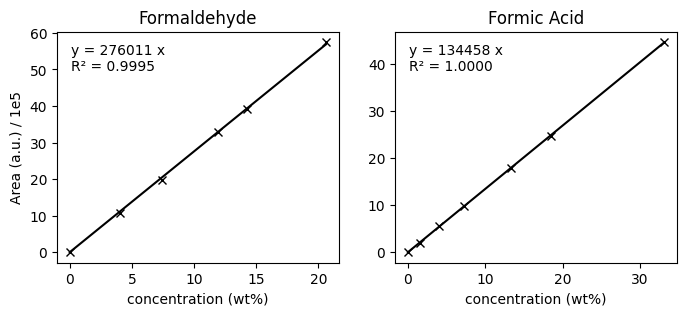

In [281]:
# calculate fit parameters and R² for each calibration series
for dictionary in np.array([FAld, FA]):                                                                                      
    m, residuals, _, _ = np.linalg.lstsq(dictionary['concentrations'].reshape(-1,1), dictionary['areas'])
    slope = m[0]
    dictionary['slope'] = slope                                                                                          
    r2 = R_sq(lambda x: slope*x, dictionary['concentrations'], dictionary['areas'])
    dictionary['r2'] = r2

# plot
fig, (ax1, ax2) = plt.subplots(figsize = (8, 3), ncols = 2)                                 
for dictionary, ax in zip(np.array([FAld, FA]), [ax1, ax2]):                                           
    ax.plot(dictionary['concentrations'], dictionary['areas']/1e5, 'kx')            
    ax.plot(dictionary['concentrations'], dictionary['concentrations']*dictionary['slope']/1e5, 'k-')     
    ax.set_title(dictionary['name'])                                                                
    ax.set_xlabel('concentration (wt%)')                                                            
    eq_text = f"y = {dictionary['slope']:.0f} x\nR² = {dictionary['r2']:.4f}"
    ax.text(0.05, 0.95, eq_text, transform=ax.transAxes, va='top')
ax1.set_ylabel('Area (a.u.) / 1e5')                                                                 
plt.show()

## Chromatogram Extraction

In [282]:
def extract_chromatogram(filepath):                                         # definiere funktion
    with open(filepath, 'r', encoding='latin1') as f:                       # öffne file as f im lesemode
        lines = f.readlines()                                               # lies die zeilen

    for i, line in enumerate(lines):
        if line.strip().startswith('[LC Chromatogram(Detector B-Ch1)]'):    # sucht start des chromatogramms
            data_start = i + 8                                              # Skip 8 header lines
            break                                                           # brich loop ab, start gefunden

    data_lines = [] 
    for line in lines[data_start:]:                                         # fang beim start neuen loop an
        if not line.strip() or line.strip().startswith('['):                # abbrechen, wenn leere zeile
            break
        data_lines.append(line)                                             # sonst, zeile an data lines anhängen

    data = np.genfromtxt(data_lines, usecols=(0,1))                         # extract data
    data_export = np.column_stack([60*data[:,0], data[:,1]])                # time --> s 
    return data_export                                                      # return the data for chromatogram

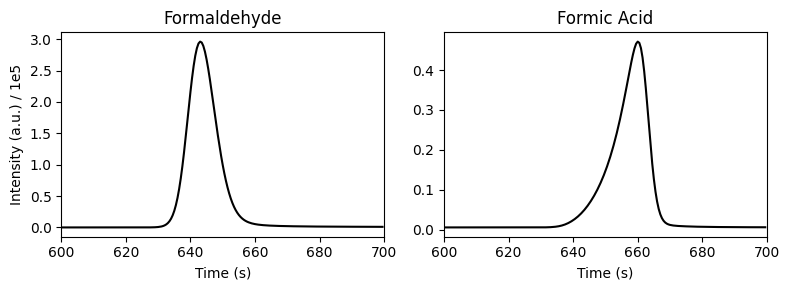

In [283]:
path = 'data/calibration/'
file = ['CAL-FALD-1.txt', 'CAL-FA-1.txt']

# load samples for each calibration (FAld, FA)
samples = [extract_chromatogram(path + f) for f in file]
index_1, index_2 = 1200, 1400  # indices for zoomed-in plot

fig, axes = plt.subplots(ncols=2, figsize=(8,3))
titles = ['Formaldehyde', 'Formic Acid']
for ax, samp, title in zip(axes, samples, titles):
    ax.plot(samp[index_1:index_2,0], samp[index_1:index_2,1] / 1e5, 'k-')
    ax.set_xlim(samp[index_1,0], samp[index_2,0])
    ax.set_title(title)

axes[0].set_ylabel('Intensity (a.u.) / 1e5')
for ax in axes:
    ax.set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## Sigma and Tau determination for Formaldehyde 

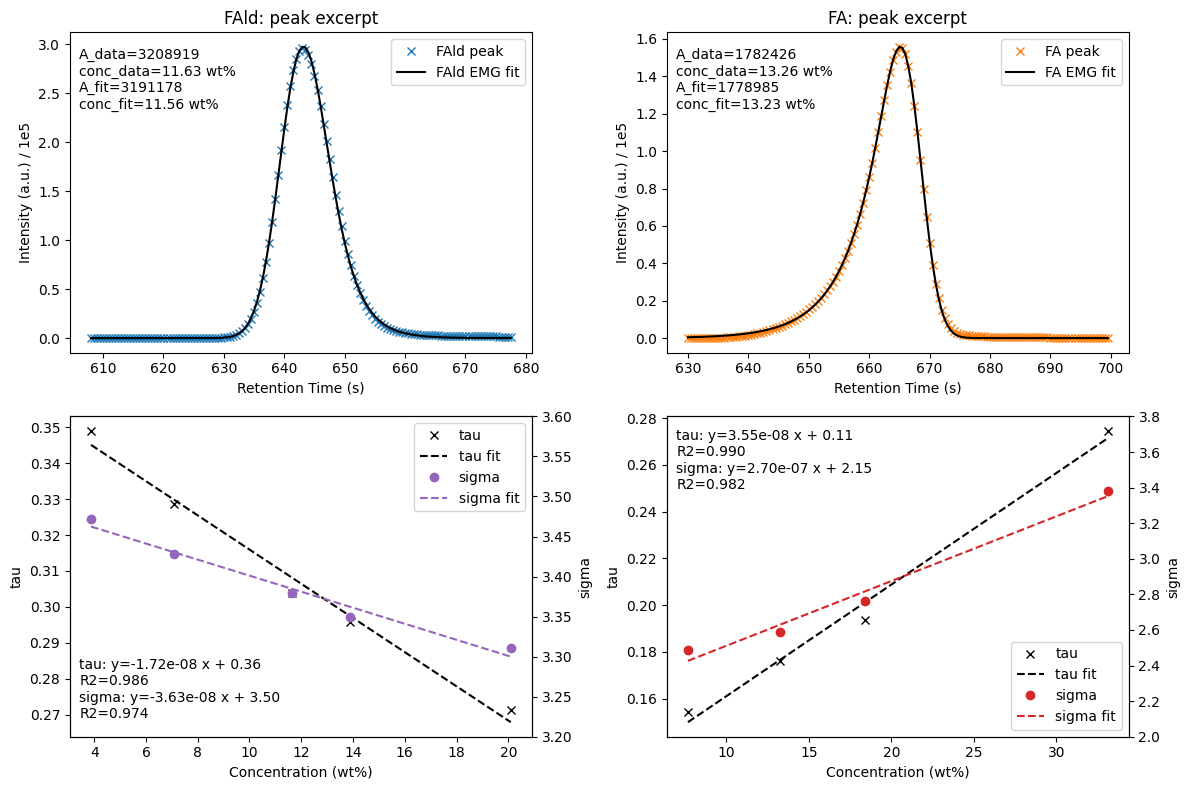

In [284]:
path_1 = 'data/calibration/'
fald_files = sorted(glob.glob(path_1 + 'CAL-FALD-*.txt'))
fa_files = sorted(glob.glob(path_1 + 'CAL-FA-*.txt'))

def analyze_calibration(files, species):
    """Fit the main peak of each trace and collect calibration metrics."""
    areas, hs, taus, sigmas, used_files = [], [], [], [], []
    model = EMG if species == 'FAld' else EMG_mirrored # choose model based on species for tailing and fronting
    sigma0, tau0 = (3.3, 0.31) if species == 'FAld' else (2.5, 0.18) # initial guesses for sigma and tau
    for file in files:
        sample = extract_chromatogram(file)
        idx_max = np.argmax(sample[:,1])
        i1, i2 = max(0, idx_max - 70), min(len(sample), idx_max + 70)
        x = sample[i1:i2,0]
        y = sample[i1:i2,1]
        p0 = [np.max(y), x[np.argmax(y)], sigma0, tau0]
        popt, _ = sc.optimize.curve_fit(model, x, y, p0=p0)
        h, mu, sigma, tau = popt
        used_files.append(file)
        areas.append(trapezoid(y, x))
        hs.append(h)
        taus.append(tau)
        sigmas.append(sigma)
    return np.array(areas), np.array(hs), np.array(taus), np.array(sigmas), used_files

def fit_info(x, y):
    """Return a simple linear calibration fit and its R²."""
    coeffs = np.polyfit(x, y, 1)
    return coeffs, R_sq(np.poly1d(coeffs), x, y)

FAld_area_arr, FAld_h_arr, FAld_tau_arr, FAld_width_arr, FAld_used = analyze_calibration(fald_files, 'FAld')
FA_area_arr, FA_h_arr, FA_tau_arr, FA_width_arr, FA_used = analyze_calibration(fa_files, 'FA')

#Exclude first two points of FA calibration for fitting
FA_fit_mask = np.argsort(FA_area_arr)[2:]
FA_area_fit = FA_area_arr[FA_fit_mask]
FA_tau_fit = FA_tau_arr[FA_fit_mask]
FA_width_fit = FA_width_arr[FA_fit_mask]

FAld_fit_tau = fit_info(FAld_area_arr, FAld_tau_arr)
FAld_fit_sig = fit_info(FAld_area_arr, FAld_width_arr)
FA_fit_tau = fit_info(FA_area_fit, FA_tau_fit)
FA_fit_sig = fit_info(FA_area_fit, FA_width_fit)

def plot_peak(ax, file, model, color, sigma_guess, tau_guess, title, slope):
    """Plot a peak excerpt and overlay the local EMG fit."""
    sample = extract_chromatogram(file)
    idx_max = np.argmax(sample[:,1])
    i1, i2 = max(0, idx_max - 70), min(len(sample), idx_max + 70)
    x = sample[i1:i2,0]
    y = sample[i1:i2,1]
    p0 = [np.max(y), x[np.argmax(y)], sigma_guess, tau_guess]
    popt, _ = sc.optimize.curve_fit(model, x, y, p0=p0)
    fit = model(x, *popt)
    ax.plot(x, y/1e5, color + 'x', label=f'{title} peak')
    ax.plot(x, fit/1e5, 'k-', label=f'{title} EMG fit')
    A_data = trapezoid(y, x)
    A_fit = popt[0]
    conc_data = A_data / slope
    conc_fit = A_fit / slope
    ax.text(0.02, 0.95, f'A_data={A_data:.0f}\nconc_data={conc_data:.2f} wt%\nA_fit={A_fit:.0f}\nconc_fit={conc_fit:.2f} wt%', transform=ax.transAxes, va='top')
    ax.set_title(f'{title}: peak excerpt')
    ax.set_xlabel('Retention Time (s)')
    ax.set_ylabel('Intensity (a.u.) / 1e5')
    ax.legend()

def plot_calibration(ax, area_arr, tau_arr, wid_arr, slope, fit_tau, fit_sig, tau_color, sig_color, label):
    """Plot tau and sigma trends versus concentration."""
    conc = area_arr / slope
    if label == 'FA':
        display_mask = np.argsort(conc)[2:]
        conc = conc[display_mask]
        tau_arr = tau_arr[display_mask]
        wid_arr = wid_arr[display_mask]
    ax2 = ax.twinx()
    ax.plot(conc, tau_arr, tau_color, label='tau')
    ax2.plot(conc, wid_arr, sig_color, label='sigma')
    if label == 'FAld':
        ax2.set_ylim(3.2, 3.6)
    else:
        ax2.set_ylim(2.0, 3.8)
    xs = np.linspace(np.min(conc), np.max(conc), 100)
    tau_fit_color = tau_color[:2] if tau_color.startswith('C') else tau_color[0]
    sig_fit_color = sig_color[:2] if sig_color.startswith('C') else sig_color[0]
    coeffs, r2 = fit_tau
    ax.plot(xs, np.poly1d(coeffs)(xs * slope), color=tau_fit_color, linestyle='--', label='tau fit')
    tau_text = f'tau: y={coeffs[0]:.2e} x + {coeffs[1]:.2f}\nR2={r2:.3f}'
    coeffs, r2 = fit_sig
    ax2.plot(xs, np.poly1d(coeffs)(xs * slope), color=sig_fit_color, linestyle='--', label='sigma fit')
    sigma_text = f'sigma: y={coeffs[0]:.2e} x + {coeffs[1]:.2f}\nR2={r2:.3f}'
    if label == 'FAld':
        ax.text(0.02, 0.05, tau_text + '\n' + sigma_text, transform=ax.transAxes, va='bottom')
    else:
        ax.text(0.02, 0.96, tau_text + '\n' + sigma_text, transform=ax.transAxes, va='top')
    ax.set_xlabel('Concentration (wt%)')
    ax.set_ylabel('tau')
    ax2.set_ylabel('sigma')
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='best')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_peak(axes[0,0], FAld_used[0], EMG, 'C0', FAld_width_arr[0], FAld_tau_arr[0], 'FAld', FAld['slope'])
plot_peak(axes[0,1], FA_used[np.argmin(np.abs(FA_area_arr / FA['slope'] - 12))], EMG_mirrored, 'C1', FA_width_arr[np.argmin(np.abs(FA_area_arr / FA['slope'] - 12))], FA_tau_arr[np.argmin(np.abs(FA_area_arr / FA['slope'] - 12))], 'FA', FA['slope'])
plot_calibration(axes[1,0], FAld_area_arr, FAld_tau_arr, FAld_width_arr, FAld['slope'], FAld_fit_tau, FAld_fit_sig, 'kx', 'C4o', 'FAld')
plot_calibration(axes[1,1], FA_area_arr, FA_tau_arr, FA_width_arr, FA['slope'], FA_fit_tau, FA_fit_sig, 'kx', 'C3o', 'FA')
fig.tight_layout()
plt.show()

In [285]:
#Tests with preset FAld and FA concentration
FAld_conc, FA_conc = 5.64, 9.53                                                     # wt% of base concentrations
Names = np.array(['FAFAld1', 'FAFAld2', 'FAFAld3', 'FAFAld4', 'FAFAld5', 'FAFALD6'])                      # Names of the mixtures
FAld_mass = np.array([0.4588, 0.9178, 0.6543, 0.5735, 0.4492,0.2454])                              # masses FAld
FA_mass = np.array([0.6864, 0.3066, 0.5077, 0.9715, 0.5593,0.3887]) 
Water_mass = np.array([0, 0, 0, 0, 0.4244,0.6128])                               # masses FA
wt_perc_FAld = FAld_conc*FAld_mass/(FAld_mass+FA_mass+Water_mass)                              # calculation of wt%
wt_perc_FA = FA_conc*FA_mass/(FAld_mass+FA_mass+Water_mass)

col_width = 20
header = f"{'Name':^{col_width}} {'wt% Formaldehyde':^{col_width}} {'wt% Formic Acid':^{col_width}}"
print(header)
print('-' * len(header))
for name, wtFAld, wtFA in zip(Names, wt_perc_FAld, wt_perc_FA):
    print(f"{name:^{col_width}} {wtFAld:^{col_width}.2f} {wtFA:^{col_width}.2f}")

        Name           wt% Formaldehyde     wt% Formic Acid   
--------------------------------------------------------------
      FAFAld1                2.26                 5.71        
      FAFAld2                4.23                 2.39        
      FAFAld3                3.18                 4.16        
      FAFAld4                2.09                 5.99        
      FAFAld5                1.77                 3.72        
      FAFALD6                1.11                 2.97        


Unconstrained fit
===============================TEST-FAFALD-1.txt================================
   Peak        h         mu     sigma     tau    Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
   FALD      652319    641.0    3.361    0.261     643.5       2.26       2.36   
    FA       758030    664.2    2.428    0.166     661.5       5.71       5.64   

===============================TEST-FAFALD-2.txt================================
   Peak        h         mu     sigma     tau    Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
   FALD     1278887    640.9    3.395    0.243     643.5       4.23       4.63   
    FA       209865    659.8    2.401    0.300     658.0       2.39       1.56   

===============================TEST-FAFALD-5.txt================================
   Peak        h         mu     sigma     tau    Peak pos.   wt% real   wt% fit  
-

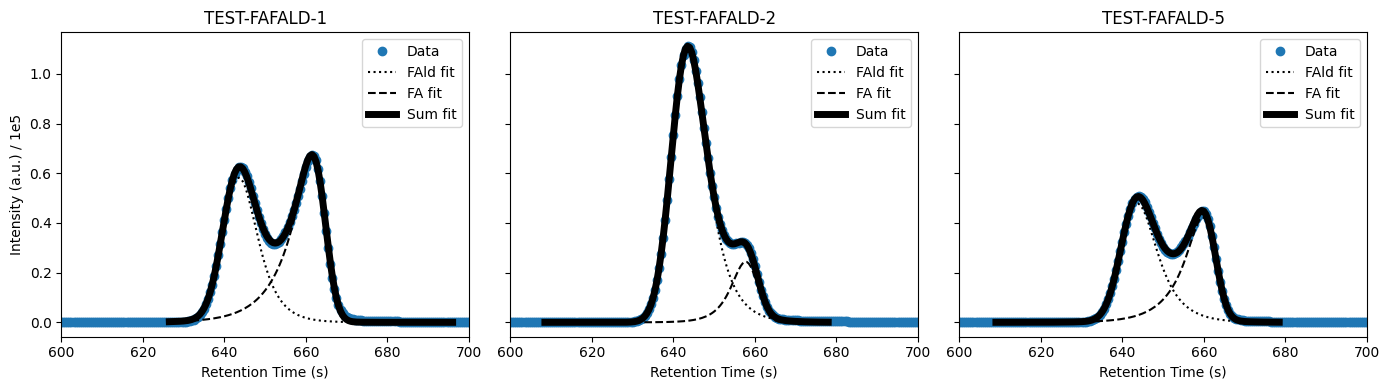

In [287]:
#Unconstrained fit
print('Unconstrained fit')
path_1 = 'data/calibration/'
sample_specs = [
    ('TEST-FAFALD-1.txt', wt_perc_FAld[0], wt_perc_FA[0]),
    ('TEST-FAFALD-2.txt', wt_perc_FAld[1], wt_perc_FA[1]),
    ('TEST-FAFALD-5.txt', wt_perc_FAld[4], wt_perc_FA[4]),
]

fig, axes = plt.subplots(ncols=3, figsize=(14, 4), sharey=True)

for ax, (sample_file, wt_fald_real, wt_fa_real) in zip(axes, sample_specs):
    print(sample_file.center(80, '='))
    print(f"{'Peak':^10} {'h':^10} {'mu':^8} {'sigma':^8} {'tau':^8} {'Peak pos.':^10} {'wt% real':^10} {'wt% fit':^10}")
    print('- ' * 40)

    sample = extract_chromatogram(path_1 + sample_file)
    index_1 = max(0, np.argmax(sample[:,1]) - 70)
    index_2 = min(len(sample), np.argmax(sample[:,1]) + 70)

    initial_guess = [1e5, 644, 3.625, 0.33, 1e4, 660, 2.665, 0.1634]
    lower_bounds = [0, 640, 0, 0, 0, 658, 0, 0]
    upper_bounds = [np.inf, 645, 4, 0.7, np.inf, 666, 3, 0.3]
    popt, _ = sc.optimize.curve_fit(EMGsTailFront, sample[index_1:index_2,0], sample[index_1:index_2,1],
                                    p0=initial_guess, bounds=[lower_bounds, upper_bounds])
    h1, mu1, sigma1, tau1 = popt[:4]
    h2, mu2, sigma2, tau2 = popt[4:]

    #calculate fit functions
    EMG_FAld = EMG(sample[index_1:index_2,0], h1, mu1, sigma1, tau1)
    EMG_FA = EMG_mirrored(sample[index_1:index_2,0], h2, mu2, sigma2, tau2)

    print(f"{'FALD':^10} {h1:^10.0f} {mu1:^8.1f} {sigma1:^8.3f} {tau1:^8.3f} {sample[index_1:index_2,0][np.argmax(EMG_FAld)]:^10.1f} {wt_fald_real:^10.2f} {h1/FAld['slope']:^10.2f}")
    print(f"{'FA':^10} {h2:^10.0f} {mu2:^8.1f} {sigma2:^8.3f} {tau2:^8.3f} {sample[index_1:index_2,0][np.argmax(EMG_FA)]:^10.1f} {wt_fa_real:^10.2f} {h2/FA['slope']:^10.2f}")
    print()
    #plot
    ax.plot(sample[:,0], sample[:,1] / 1e5, 'C0o')
    ax.plot(sample[index_1:index_2,0], EMG_FAld / 1e5, 'k:')
    ax.plot(sample[index_1:index_2,0], EMG_FA / 1e5, 'k--')
    ax.plot(sample[index_1:index_2,0], (EMG_FAld + EMG_FA) / 1e5, 'k-', lw=5)
    ax.set_xlim(600, 700)
    ax.set_title(sample_file.replace('.txt', ''))
    ax.set_xlabel('Retention Time (s)')
    ax.legend(['Data', 'FAld fit', 'FA fit', 'Sum fit'])

axes[0].set_ylabel('Intensity (a.u.) / 1e5')
fig.tight_layout()
plt.show()

Constrained fit - only sigma
===============================TEST-FAFALD-1.txt================================
   Peak        h         mu     sigma     tau    Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
   FALD      620849    641.3    0.952    0.311     643.5       2.26       2.25   
    FA       792072    664.3    1.196    0.153     661.5       5.71       5.89   

===============================TEST-FAFALD-2.txt================================
   Peak        h         mu     sigma     tau    Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
   FALD     1238819    641.0    0.929    0.267     643.5       4.23       4.49   
    FA       248596    660.1    1.049    0.215     658.0       2.39       1.85   

===============================TEST-FAFALD-5.txt================================
   Peak        h         mu     sigma     tau    Peak pos.   wt% real   

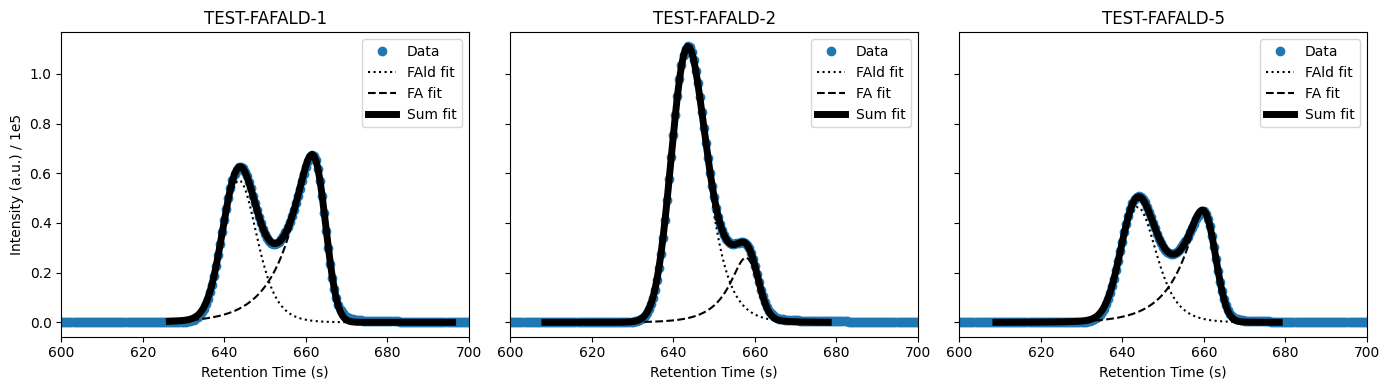

In [288]:
#Constrained fit - only sigma
print('Constrained fit - only sigma')
path_1 = 'data/calibration/'
sample_specs = [
    ('TEST-FAFALD-1.txt', wt_perc_FAld[0], wt_perc_FA[0]),
    ('TEST-FAFALD-2.txt', wt_perc_FAld[1], wt_perc_FA[1]),
    ('TEST-FAFALD-5.txt', wt_perc_FAld[4], wt_perc_FA[4]),
]

# Use factory functions from fit_functions to avoid local duplicates
# Create sigma-constrained EMG functions using the calibration fit coefficients
constrained_EMG = make_sigma_constrained_EMG(FAld_fit_sig[0])
constrained_EMG_mirrored = make_sigma_constrained_EMG_mirrored(FA_fit_sig[0])
constrained_EMGsTailFront = make_sigma_constrained_EMGsTailFront(FAld_fit_sig[0], FA_fit_sig[0])

fig, axes = plt.subplots(ncols=3, figsize=(14, 4), sharey=True)
s = lambda value: float(np.ravel(value)[0])

for ax, (sample_file, wt_fald_real, wt_fa_real) in zip(axes, sample_specs):
    print(sample_file.center(80, '='))
    print(f"{'Peak':^10} {'h':^10} {'mu':^8} {'sigma':^8} {'tau':^8} {'Peak pos.':^10} {'wt% real':^10} {'wt% fit':^10}")
    print('- ' * 40)

    sample = extract_chromatogram(path_1 + sample_file)
    index_1 = max(0, np.argmax(sample[:,1]) - 70)
    index_2 = min(len(sample), np.argmax(sample[:,1]) + 70)

    initial_guess = [8e5, 644, 0.35, 1e4, 660, 0.13]
    lower_bounds = [0, 640, 0, 0, 660, 0]
    upper_bounds = [np.inf, 650, 0.5, np.inf, 666, 0.5]
    popt, _ = sc.optimize.curve_fit(constrained_EMGsTailFront, sample[index_1:index_2,0], sample[index_1:index_2,1],
                                    p0=initial_guess, bounds=[lower_bounds, upper_bounds])
    h1, mu1, tau1 = popt[:3]
    sigma1 = FAld_fit_sig[1] + h1 * FAld_fit_sig[0]
    h2, mu2, tau2 = popt[3:]
    sigma2 = FA_fit_sig[1] + h2 * FA_fit_sig[0]

    #calculate fit functions
    EMG_FAld = constrained_EMG(sample[index_1:index_2,0], h1, mu1, tau1)
    EMG_FA = constrained_EMG_mirrored(sample[index_1:index_2,0], h2, mu2, tau2)

    print(f"{'FALD':^10} {s(h1):^10.0f} {s(mu1):^8.1f} {s(sigma1):^8.3f} {s(tau1):^8.3f} {s(sample[index_1:index_2,0][np.argmax(EMG_FAld)]):^10.1f} {wt_fald_real:^10.2f} {s(h1/FAld['slope']):^10.2f}")
    print(f"{'FA':^10} {s(h2):^10.0f} {s(mu2):^8.1f} {s(sigma2):^8.3f} {s(tau2):^8.3f} {s(sample[index_1:index_2,0][np.argmax(EMG_FA)]):^10.1f} {wt_fa_real:^10.2f} {s(h2/FA['slope']):^10.2f}")
    print()

    #plot
    ax.plot(sample[:,0], sample[:,1] / 1e5, 'C0o')
    ax.plot(sample[index_1:index_2,0], EMG_FAld / 1e5, 'k:')
    ax.plot(sample[index_1:index_2,0], EMG_FA / 1e5, 'k--')
    ax.plot(sample[index_1:index_2,0], (EMG_FAld + EMG_FA) / 1e5, 'k-', lw=5)
    ax.set_xlim(600, 700)
    ax.set_title(sample_file.replace('.txt', ''))
    ax.set_xlabel('Retention Time (s)')
    ax.legend(['Data', 'FAld fit', 'FA fit', 'Sum fit'])

axes[0].set_ylabel('Intensity (a.u.) / 1e5')
fig.tight_layout()
plt.show()

Constrained fit - only tau
===============================TEST-FAFALD-1.txt================================
   Peak        h         mu     sigma     tau    Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
   FALD      520049    641.4    2.500    0.355     643.5       2.26       1.88   
    FA       848579    664.2    2.500    0.143     661.5       5.71       6.31   

===============================TEST-FAFALD-2.txt================================
   Peak        h         mu     sigma     tau    Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
   FALD      969004    641.3    2.500    0.347     643.0       4.23       3.51   
    FA       461265    660.0    2.500    0.130     657.0       2.39       3.43   

===============================TEST-FAFALD-5.txt================================
   Peak        h         mu     sigma     tau    Peak pos.   wt% real   wt

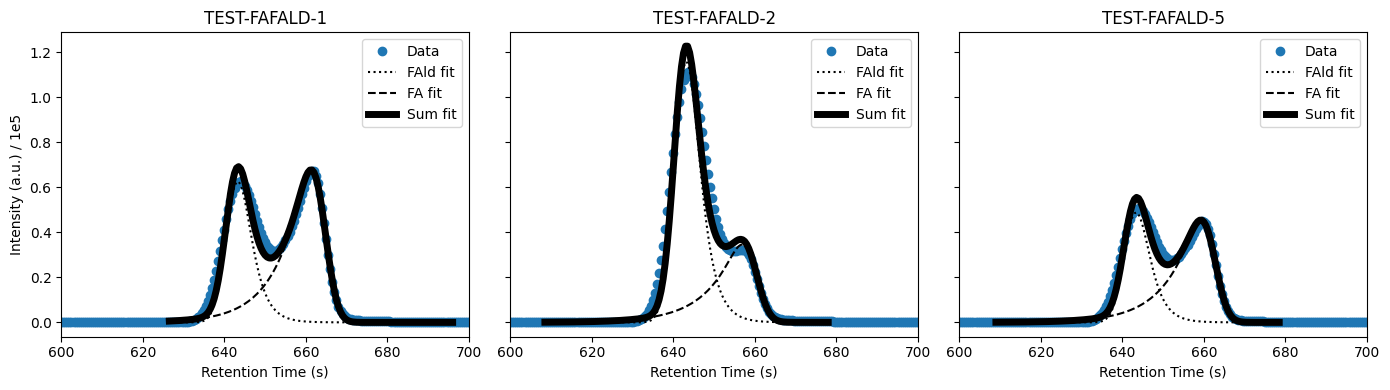

In [289]:
# Constrained fit - only tau
print('Constrained fit - only tau')
path_1 = 'data/calibration/'
sample_specs = [
    ('TEST-FAFALD-1.txt', wt_perc_FAld[0], wt_perc_FA[0]),
    ('TEST-FAFALD-2.txt', wt_perc_FAld[1], wt_perc_FA[1]),
    ('TEST-FAFALD-5.txt', wt_perc_FAld[4], wt_perc_FA[4]),
]

# Build tau-constrained models from linear calibration fits
FAld_tau_coeffs = FAld_fit_tau[0]
FA_tau_coeffs = FA_fit_tau[0]

def tau_constrained_EMG(x, h, mu, sigma):
    tau = FAld_tau_coeffs[1] + h * FAld_tau_coeffs[0]
    return EMG(x, h, mu, sigma, tau)

def tau_constrained_EMG_mirrored(x, h, mu, sigma):
    tau = FA_tau_coeffs[1] + h * FA_tau_coeffs[0]
    return EMG_mirrored(x, h, mu, sigma, tau)

def tau_constrained_EMGsTailFront(x, h1, mu1, sigma1, h2, mu2, sigma2):
    return tau_constrained_EMG(x, h1, mu1, sigma1) + tau_constrained_EMG_mirrored(x, h2, mu2, sigma2)

fig, axes = plt.subplots(ncols=3, figsize=(14, 4), sharey=True)
s = lambda value: float(np.ravel(value)[0])

for ax, (sample_file, wt_fald_real, wt_fa_real) in zip(axes, sample_specs):
    print(sample_file.center(80, '='))
    print(f"{'Peak':^10} {'h':^10} {'mu':^8} {'sigma':^8} {'tau':^8} {'Peak pos.':^10} {'wt% real':^10} {'wt% fit':^10}")
    print('- ' * 40)

    sample = extract_chromatogram(path_1 + sample_file)
    index_1 = max(0, np.argmax(sample[:,1]) - 70)
    index_2 = min(len(sample), np.argmax(sample[:,1]) + 70)

    initial_guess = [8e5, 644, 0.95, 1e4, 660, 1.10]
    lower_bounds = [0, 640, 0, 0, 660, 0]
    upper_bounds = [np.inf, 650, 2.5, np.inf, 666, 2.5]
    popt, _ = sc.optimize.curve_fit(
        tau_constrained_EMGsTailFront,
        sample[index_1:index_2,0],
        sample[index_1:index_2,1],
        p0=initial_guess,
        bounds=[lower_bounds, upper_bounds],
    )

    h1, mu1, sigma1 = popt[:3]
    tau1 = FAld_tau_coeffs[1] + h1 * FAld_tau_coeffs[0]
    h2, mu2, sigma2 = popt[3:]
    tau2 = FA_tau_coeffs[1] + h2 * FA_tau_coeffs[0]

    EMG_FAld = tau_constrained_EMG(sample[index_1:index_2,0], h1, mu1, sigma1)
    EMG_FA = tau_constrained_EMG_mirrored(sample[index_1:index_2,0], h2, mu2, sigma2)

    print(f"{'FALD':^10} {s(h1):^10.0f} {s(mu1):^8.1f} {s(sigma1):^8.3f} {s(tau1):^8.3f} {s(sample[index_1:index_2,0][np.argmax(EMG_FAld)]):^10.1f} {wt_fald_real:^10.2f} {s(h1/FAld['slope']):^10.2f}")
    print(f"{'FA':^10} {s(h2):^10.0f} {s(mu2):^8.1f} {s(sigma2):^8.3f} {s(tau2):^8.3f} {s(sample[index_1:index_2,0][np.argmax(EMG_FA)]):^10.1f} {wt_fa_real:^10.2f} {s(h2/FA['slope']):^10.2f}")
    print()

    ax.plot(sample[:,0], sample[:,1] / 1e5, 'C0o')
    ax.plot(sample[index_1:index_2,0], EMG_FAld / 1e5, 'k:')
    ax.plot(sample[index_1:index_2,0], EMG_FA / 1e5, 'k--')
    ax.plot(sample[index_1:index_2,0], (EMG_FAld + EMG_FA) / 1e5, 'k-', lw=5)
    ax.set_xlim(600, 700)
    ax.set_title(sample_file.replace('.txt', ''))
    ax.set_xlabel('Retention Time (s)')
    ax.legend(['Data', 'FAld fit', 'FA fit', 'Sum fit'])

axes[0].set_ylabel('Intensity (a.u.) / 1e5')
fig.tight_layout()
plt.show()

In [ ]:
#import chromatogram
print('Constrained fit')
print('-'*80)
path_35 = 'data/calibration/'
files_35 = sorted(glob.glob(path_35 + 'CAL-*.txt'))

path_35_2 = 'data/calibration/'
files_35_2 = sorted(glob.glob(path_35_2 + 'TEST-FAFALD-*.txt'))

# Use factory functions from fit_functions to build constrained models
constrained_EMG = make_constrained_EMG(FAld_coeffs_tau, FAld_coeffs_wid)
constrained_EMG_mirrored = make_constrained_EMG_mirrored(FA_coeffs_tau, FA_coeffs_wid)
constrained_EMGsTailFront = make_constrained_EMGsTailFront(
    FAld_coeffs_tau,
    FAld_coeffs_wid,
    FA_coeffs_tau,
    FA_coeffs_wid,
 )

initial_guess = [1e7, 644, 1e5, 658]                                                                                    # define initial guesses and bounds
lower_bounds = [1, 630, 1, 656]
upper_bounds = [np.inf, 645, np.inf, 665]

popt, _ = sc.optimize.curve_fit(constrained_EMGsTailFront, sample[index_1:index_2,0], sample[index_1:index_2,1],        # calculate popt
                                p0 = initial_guess, bounds = [lower_bounds, upper_bounds])

h1, mu1 = popt[:2]                                                                                                      # calculate sigma and tau
sigma1 = FAld_coeffs_wid[1]+h1*FAld_coeffs_wid[0]
tau1 = FAld_coeffs_tau[1]+h1*FAld_coeffs_tau[0]
h2, mu2 = popt[2:]
sigma2 = FA_coeffs_wid[1]+h2*FA_coeffs_wid[0]
tau2 = FA_coeffs_tau[1]+h2*FA_coeffs_tau[0]

EMG_FAld = constrained_EMG(sample[index_1:index_2,0], h1, mu1)                                                          # calculate fit functions
EMG_FA   = constrained_EMG_mirrored(sample[index_1:index_2,0], h2, mu2)

print(f"{'Peak':<10} {'h':<12} {'mu':<10} {'sigma':<10} {'tau':<10} {'[wt%]':<12} {'Peak pos.':<12}")                   #print Peak pos and popt
print("-" * 80)
print(f"{'FAld':<10} {h1:<12.2f} {mu1:<10.3f} {sigma1:<10.3f} {tau1:<10.3f} {h1/FAld['slope']:<12.2f} {sample[index_1:index_2,0][np.argmax(EMG_FAld)]:<12.2f}")
print(f"{'FA':<10} {h2:<12.2f} {mu2:<10.3f} {sigma2:<10.3f} {tau2:<10.3f} {h2/FA['slope']:<12.2f} {sample[index_1:index_2,0][np.argmax(EMG_FA)]:<12.2f}")

fig, ax = plt.subplots(figsize = (4,2.5))                                                                                #plot
ax.plot(sample[:,0], sample[:,1], 'C0o', label='Data')
ax.plot(sample[index_1:index_2,0], EMG_FAld, 'k:', label='FAld fit')
ax.plot(sample[index_1:index_2,0], EMG_FA, 'k--', label='FA fit')
ax.plot(sample[index_1:index_2,0], EMG_FAld+EMG_FA, 'k-', lw = 5, label='Sum fit')
ax.set_xlim(600, 700)
ax.set_xlabel('Retention Time (s)')
ax.set_ylabel('Intensity (a.u.)')
ax.legend()
plt.show()

Constrained fit
--------------------------------------------------------------------------------


NameError: name 'FAld_coeffs_tau' is not defined